<a href="https://colab.research.google.com/github/nestorveas/Tarea2_gf0657/blob/main/Tarea2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 2: Datos de Asadas de Costa Rica

Autor: Néstor Veas Ayala
Carné: A13865

## Introducción
El trabajo en el curso *[Programación en SIG (GF-0657)](https://gf0657-programacionsig.github.io/2026-ii/)* busca generar respuestas respecto a diferentes datos de las diferentes Asociaciones Administradoras de Acueducto y Alcantarillado Rural, comúnmente llamadas *ASADAS*, en Costa Rica.

Esta figura legal es una de las cuatro que Costa Rica tiene autorizada para brindar el servicio público de abastecimiento de agua potable y saneamiento, siendo las otras tres el propio Instituto Costarricense de Acueductos y Alcantarillados (AyA), Municipalidades, y la Empresa de Servicios Públicos de Heredia (ESPH).


### ¿Qué son las ASADAS?

Este tipo de acueductos abastecen a casi un 25% de la población en más de 1400 entidades a nivel nacional [(AyA, 2020)](https://dspaceaya.igniteonline.la/server/api/core/bitstreams/0b743fb2-d3ec-4cf0-a66d-d10ece8ab3ef/content), y tienen una importancia especial ya que son administradas de manera comunal. Lo anterior implica que los miembros de las Juntas Directivas de cada ASADA son personas de la o las comunidades abastecidas, y que los cobros por el servicio, asi como el mantenimiento y ampliaciones del acueducto, las compras y actividades son gestionadas por cada ASADA.

Es importante indicar que las ASADAS son supervisadas y tuteladas a nivel normativo y técnico por el **(AyA)**

### Datos respecto a las ASADAS

A continuación se presenta la base de datos que se utilizará para trabajar y generar respuestas respecto a la información de las distintas ASADAS del país para el año 2024. La fuente de esta base de datos es el Sistema de Apoyo para la Gestión de Asadas (SAGA) del AyA.

Esta infomación incluye datos relevantes a saber:

1. Código de cada ASADA
2. Cantidad de servicios abastecidos
3. Número de habitantes abastecidos
4. Cantidad de hidrantes en cada ASADA
5. Nombre oficial de cada ASADA

### Preguntas

Para entender y contextualizar el presente de las ASADAS en Costa Rica la información nos ayudará a responder algunas dudas, por ejemplo:

- ¿Cuánta población abastecen las ASADAS?
- ¿Qué provincia posee más ASADAS en el país?
- ¿Cuál es el promedio de servicios y habitantes abastecidos por cada ASADA?

## Carga y preparación de datos

In [ ]:
import pandas as pd
import plotly.express as px
from IPython.display import display
import matplotlib.pyplot as plt


In [ ]:
# Carga del archivo CSV de asadas en un DataFrame
asadas = pd.read_csv("asadas_t4.csv", sep=";", encoding="cp1252")

# Primeras filas
asadas.head()

,PKREGION,Región,PKENTEOPERADOR,IDEO,Código_Geográfico,Provincia,Cantón,Cod_Canton,Distrito,Nombre_Operador,...,FIJOPREFERENCIAL,MEDIDOPREFERENCIAL,HIDRANTESERVICIO,Fecha_Servicio,Servicios_abastecidos,Servicios_proyectados20anos,Poblacion_abastecida,Poblacion_abastecida_proyectada20anos,Rangos_servicios_99_300_700_mas800,Rangos_servicios_99_400_700_mas800
0,1276,Región Chorotega,2181,00220-2014,5-7-1,GUANACASTE,ABANGARES,507,LAS JUNTAS,"CONCEPCION DE COLORADO DE ABANGARES, GUANACASTE",...,0.0,0.0,NaN,2018-12-19,90.0,171.0,315.0,598.50,0-99,0-99
1,1276,Región Chorotega,2182,00221-2014,5-7-1,GUANACASTE,ABANGARES,507,LAS JUNTAS,"LA PALMA DE LAS JUNTAS DE ABANGARES, GUANACASTE",...,0.0,0.0,NaN,2018-12-19,257.0,488.3,899.5,1709.05,100-299,100-400
2,1276,Región Chorotega,2183,00222-2014,5-7-1,GUANACASTE,ABANGARES,507,LAS JUNTAS,LIMONAL DE LAS JUNTAS DE ABANGARES GUANACASTE,...,0.0,0.0,3.0,2018-12-19,205.0,389.5,717.5,1363.25,100-299,100-400
3,1276,Región Chorotega,2184,00223-2014,5-7-1,GUANACASTE,ABANGARES,507,LAS JUNTAS,"MATAPALO DE LAS JUNTAS DE ABANGARES, GUANACASTE",...,0.0,0.0,NaN,2018-12-19,252.0,478.8,882.0,1675.80,100-299,100-400
4,1276,Región Chorotega,2185,00225-2014,5-7-4,GUANACASTE,ABANGARES,507,COLORADO,PUEBLO NUEVO DE COLORADO DE ABANGARES GUANACASTE,...,0.0,0.0,NaN,2018-12-19,135.0,256.5,472.5,897.75,100-299,100-400


In [ ]:
# Dimensiones
asadas.shape

(1395, 30)

In [ ]:
#Tipo de datos
asadas.dtypes

,0
PKREGION,int64
Región,object
PKENTEOPERADOR,int64
IDEO,object
Código_Geográfico,object
Provincia,object
Cantón,object
Cod_Canton,int64
Distrito,object
Nombre_Operador,object


In [ ]:
# Filtrado y selección de columnas para trabajar

asadas_limpio = asadas[["Región", "IDEO", "Provincia", "Cantón", "Cod_Canton", "Nombre_Operador", "HIDRANTESERVICIO", "Servicios_abastecidos", "Poblacion_abastecida"]]

In [ ]:
asadas_limpio

,Región,IDEO,Provincia,Cantón,Cod_Canton,Nombre_Operador,HIDRANTESERVICIO,Servicios_abastecidos,Poblacion_abastecida
0,Región Chorotega,00220-2014,GUANACASTE,ABANGARES,507,"CONCEPCION DE COLORADO DE ABANGARES, GUANACASTE",NaN,90.0,315.0
1,Región Chorotega,00221-2014,GUANACASTE,ABANGARES,507,"LA PALMA DE LAS JUNTAS DE ABANGARES, GUANACASTE",NaN,257.0,899.5
2,Región Chorotega,00222-2014,GUANACASTE,ABANGARES,507,LIMONAL DE LAS JUNTAS DE ABANGARES GUANACASTE,3.0,205.0,717.5
3,Región Chorotega,00223-2014,GUANACASTE,ABANGARES,507,"MATAPALO DE LAS JUNTAS DE ABANGARES, GUANACASTE",NaN,252.0,882.0
4,Región Chorotega,00225-2014,GUANACASTE,ABANGARES,507,PUEBLO NUEVO DE COLORADO DE ABANGARES GUANACASTE,NaN,135.0,472.5
...,...,...,...,...,...,...,...,...,...
1390,Región Huetar Norte,01512-2014,ALAJUELA,ZARCERO,211,LAS BRISAS DE ZARCERO DE ALAJUELA,6.0,608.0,2128.0
1391,Región Huetar Norte,04226-2014,ALAJUELA,ZARCERO,211,"PALMIRA DE ALFARO RUIZ, ALAJUELA",12.0,355.0,1242.5
1392,Región Huetar Norte,04691-2014,ALAJUELA,ZARCERO,211,"EL CARMEN DE LAGUNA DE ALFARO RUIZ, ALAJUELA",NaN,50.0,175.0
1393,Región Huetar Norte,04692-2014,ALAJUELA,ZARCERO,211,"ZAPOTE DE LAGUNA DE ALFARO RUIZ, ALAJUELA",3.0,236.0,826.0


## Al menos una tabla

Para este trabajo, con los datos de *asadas_limpio* generaremos una nueva tabla con la que se harán los gráficos finales.

La tabla a generar (*asadas_provincia*) tendrá información por provincia, y sumará la cantidad de servicios y población de todas las asadas. Asimismo, se generará una nueva columna con la cantidad de asadas por provincia y el promedio de población abastecida y cantidad de servicios por asada por provincia.

In [ ]:
# Servicios y población abastecida por provincia

asadas_provincia =asadas_limpio.groupby("Provincia")[["Servicios_abastecidos", "Poblacion_abastecida"]].sum()

asadas_provincia

,Servicios_abastecidos,Poblacion_abastecida
Provincia,,
ALAJUELA,161472.0,565152.0
CARTAGO,48591.0,170068.5
GUANACASTE,53548.0,187418.0
HEREDIA,25080.0,87780.0
LIMON,39978.0,139923.0
PUNTARENAS,58368.0,204288.0
SAN JOSE,56954.0,199339.0


In [ ]:
# Añadir columna con la cantidad de asadas por provincia

asadas_provincia["num_asadas"] = asadas_limpio.groupby("Provincia").size()

asadas_provincia



,Servicios_abastecidos,Poblacion_abastecida,num_asadas
Provincia,,,
ALAJUELA,161472.0,565152.0,333
CARTAGO,48591.0,170068.5,132
GUANACASTE,53548.0,187418.0,299
HEREDIA,25080.0,87780.0,42
LIMON,39978.0,139923.0,121
PUNTARENAS,58368.0,204288.0,207
SAN JOSE,56954.0,199339.0,261


In [ ]:
# Añadir promedio de servicios y población abastecida por provincia (un decimal)

asadas_provincia["Prom_serv"] = (
    asadas_provincia ["Servicios_abastecidos"] / asadas_provincia["num_asadas"]
    ).round(1)

asadas_provincia["Prom_pobl"] = (
    asadas_provincia ["Poblacion_abastecida"] / asadas_provincia["num_asadas"]
    ).round(1)

asadas_provincia

,Servicios_abastecidos,Poblacion_abastecida,num_asadas,Prom_serv,Prom_pobl
Provincia,,,,,
ALAJUELA,161472.0,565152.0,333,484.9,1697.2
CARTAGO,48591.0,170068.5,132,368.1,1288.4
GUANACASTE,53548.0,187418.0,299,179.1,626.8
HEREDIA,25080.0,87780.0,42,597.1,2090.0
LIMON,39978.0,139923.0,121,330.4,1156.4
PUNTARENAS,58368.0,204288.0,207,282.0,986.9
SAN JOSE,56954.0,199339.0,261,218.2,763.8


In [ ]:
# Como la columna "Provincia" de la derecha no es parte del dataframe, manualmente incluí una columna con el nombre de cada una

asadas_provincia["Provincia"] = ["Alajuela", "Cartago", "Guanacaste", "Heredia", "Limón", "Puntarenas", "San José"]

asadas_provincia

,Servicios_abastecidos,Poblacion_abastecida,num_asadas,Prom_serv,Prom_pobl,Provincia
Provincia,,,,,,
ALAJUELA,161472.0,565152.0,333,484.9,1697.2,Alajuela
CARTAGO,48591.0,170068.5,132,368.1,1288.4,Cartago
GUANACASTE,53548.0,187418.0,299,179.1,626.8,Guanacaste
HEREDIA,25080.0,87780.0,42,597.1,2090.0,Heredia
LIMON,39978.0,139923.0,121,330.4,1156.4,Limón
PUNTARENAS,58368.0,204288.0,207,282.0,986.9,Puntarenas
SAN JOSE,56954.0,199339.0,261,218.2,763.8,San José


In [ ]:
# Finalmente pasamos los datos de servicios y población abastecida a enteros para los gráficos

asadas_provincia["Servicios_abastecidos"] = asadas_provincia["Servicios_abastecidos"].astype(int)

asadas_provincia["Poblacion_abastecida"] = asadas_provincia["Poblacion_abastecida"].astype(int)

asadas_provincia

,Servicios_abastecidos,Poblacion_abastecida,num_asadas,Prom_serv,Prom_pobl,Provincia
Provincia,,,,,,
ALAJUELA,161472,565152,333,484.9,1697.2,Alajuela
CARTAGO,48591,170068,132,368.1,1288.4,Cartago
GUANACASTE,53548,187418,299,179.1,626.8,Guanacaste
HEREDIA,25080,87780,42,597.1,2090.0,Heredia
LIMON,39978,139923,121,330.4,1156.4,Limón
PUNTARENAS,58368,204288,207,282.0,986.9,Puntarenas
SAN JOSE,56954,199339,261,218.2,763.8,San José


## Al menos tres gráficos

Se generarán los gráficos de:
- Servicios y población abastecida por provincia (Gráfico de barras)
- Cantidad de asadas por provincia (Gráfico pastel)
- Promedio de servicios y población abastecid por provincia (Gráfico de barras)

In [ ]:
# Generación del Gráfico 1

fig1 = px.bar(
    asadas_provincia.sort_values("Servicios_abastecidos", ascending=True),
    x=["Servicios_abastecidos", "Poblacion_abastecida"],
    y="Provincia",
    orientation="h",
    barmode="group", # si las queremos agrupadas poner "stack"
    title="Gráfico 1:Servicios y población abastecida por Asadas a nivel provincial, 2024",
    labels={"Provincia": " Provincia", "value": " Valor", "variable": " Dato"},
    text_auto=",.0f"
)

fig1.show()

El Gráfico 1 muestra los valores totales de servicios (cantidad de medidores) y población abastecida por Asadas a nivel provincial. Destaca el dato de Alajuela, que posee más del doble de servicios que la provincia que le sigue (Puntarenas); de igual manera se observa la cantidad de personas que se abastecen de dichos servicios donde la relación se mantiene similar.

Las otras 6 provincias mantienen valores relativamente cercanos, yendo desde los 25 mil servicios en Heredia, hasta los casi 60 mil de Puntarenas. De forma consecuente, Heredia abastece a casi 90 mil habitantes, mientras que Puntarenas supera los 200 mil personas abastecidas.

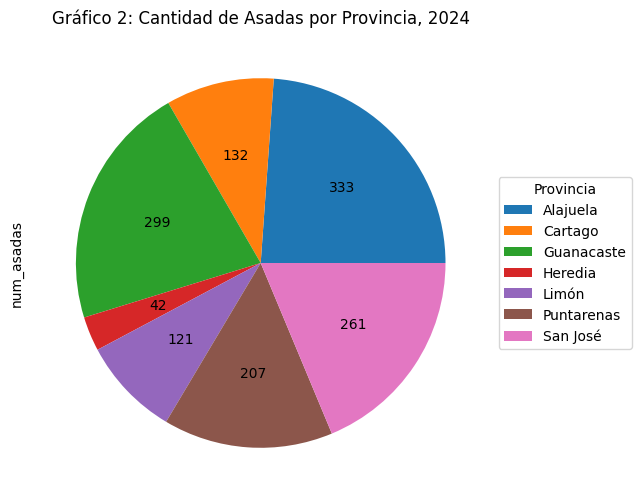

In [ ]:
fig,ax = plt.subplots(figsize=(12,6))

asadas_provincia.plot(
    x="Provincia",
    y="num_asadas",
    kind="pie",
    ax=ax,
    title="Gráfico 2: Cantidad de Asadas por Provincia, 2024",
    legend=False,
    autopct=lambda pct: f'{int(round(pct * sum(asadas_provincia["num_asadas"]) / 100.0))}',#autopct="%1.1f%%",
    labels=None
)

ax.legend(
    labels=asadas_provincia["Provincia"],
    title="Provincia",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)


A través del Gráfico 2 observamos que Alajuela es la provincia que tiene más Asadas: 333; lo anterior es consecuente con lo visto en el Gráfico 1, ya que es la misma provincia que tiene más servicios y personas abastecidas por estos operadores. Sin embargo, cabe destacar que la segunda y tercera provincia con más Asadas son Guanacaste (299) y San José (261), distinto a lo que vemos en la cantidad de usuarios y población, donde Puntarenas es la provincia que se posiciona de segunda; en el departamento de cantidad de Asadas, esta provincia es la cuarta con 207 Asadas.

In [ ]:
# Generación Gráfico 3

fig3 = px.bar(
    asadas_provincia.sort_values("Servicios_abastecidos", ascending=True),
    x="Provincia",
    y=["Prom_serv", "Prom_pobl"],
    barmode="group", # si las queremos agrupadas poner "stack"
    title="Gráfico 3:Promedio de servicios y población abastecida por Asada a nivel provincial, 2024",
    labels={"Provincia": " Provincia", "value": " Valor promedio", "variable": " Dato"},
    text_auto=",.0f"
)

# Nombres de las series en la leyenda, en lugar de los nombres de las columnas
fig3.for_each_trace(lambda traza: traza.update(name=traza.name.capitalize()))

fig3.show()

El Gráfico 3 muestra datos interesantes. En primer lugar, si bien es la provincia que menos Asadas tiene (42) y que abasteces menos servicios y población total, Heredia posee la mayor cantidad de servicios y población abastecida por Asada en el país. Este resultado es una mezcla de entes que están en zonas bastante urbanizadas, así como operadores que están en zona rural, pero cubren una gran extensión, y por ende tienen muchos servicios y abastecen a una gran cantidad de personas.

Caso contrario es el de Guanacaste. Si bien esta es la segunda provincia con más Asadas (299), su cantidad promedio de servicios y habitantes abastecidos es la menor del pais. Lo anterior indica que muchas de sus Asadas son pequeñas, lo cual es un reto a la hora de dar el servicio de agua potable, puesto que la operación de este recurso es costosa; la baja cantidad de servicios y personas hace que los ingresos para esta operación no sean los ideales, más con el agravante de ser una de las provincias con mayor escasez del recurso hídrico.

Finalmente, Alajuela es la segunda en promedio de servicios y personas abastecidas, siguiendo la línea de ser la provincia con más Asadas, servicios y población abastecida. Esto denota que estos operadores tienen una extensión considerable, abasteciendo a un número importante de abonados.

In [ ]:
# Generación Gráfico 4

top10_asadas = asadas_limpio.sort_values("Servicios_abastecidos", ascending=False).head(10)

top10_asadas["Nom_corto"] = ["Horquetas", "San Rafael Ojo de Agua", "Santa Rosa de Pocosol", "Pital", "Integrada de Sarapiquí", "Cajón", "Poás y Bo. Corzón de Jesús", "Malinches de Pinilla", "San José de Upala", "Chachagua"]

fig4 = px.bar(
    top10_asadas.sort_values("Servicios_abastecidos"),
    x="Nom_corto",
    y="Servicios_abastecidos",
    color_discrete_sequence=["#1316B6"],
    title="Gráfico 4: Las diez Asadas con mayor cantidad de servicios en Costa Rica, 2024",
    labels={"Servicios_abastecidos": "Cantidad de servicios", "Nom_corto": "Nombre de la Asada", "Provincia": "Provincia"},
    text_auto=",.0f"
)

fig4.show()



Finalmente y como un extra, el Gráfico 4 muestra las 10 Asadas del país con mayor cantidad de servicios, donde destaca la de Horquetas de Sarapiquí y sus más de 5.000 servicios. 5 de las 7 provincias están representadas en entre las 10 más grandes, quedando fuera únicamente Cartago y Limón.

## Conclusiones

Las Asadas abastecen a un cuarto de la población de Costa Rica en casi 1400 entidades [(AyA, 2020)](https://dspaceaya.igniteonline.la/server/api/core/bitstreams/0b743fb2-d3ec-4cf0-a66d-d10ece8ab3ef/content), estas asociaciones se encuentran en todas las provincias del país, y abastecen sectores urbanos y muy especialmente localidades rurales, donde de no ser por ellas, no se podría tener un servicio de agua potable seguro y eficiente.

La mayor cantidad de Asadas se encuentran en la provincia de Alajuela; esta provincia además es la que tiene mayor cantidad de servicios y personas abastecidas a nivel absoluto, con más del doble en ambos departamentos que la provincia de Puntarenas, que la sigue de lejos.

Curiosamente, la provincia con menos Asadas del país es la más eficiente respecto al promedio de servicios y habitantes se refiere. Lo anterior es importante, ya que entre más abonados tenga una Asada, más recursos tendrá para enfrentar los diferentes retos que se le presentan.



## Bibliografía

Instituto Costarricense de Acueductos y Alcantarillados (AyA), 2020. *Agua para uso y consumo humano y saneamiento en Costa Rica al 2019: Brechas y desafíos al 2023*. Laboratorio Nacional de Aguas. San José, Costa Rica. 47pp.

Sistema de Apoyo para la Gestión de Asadas (SAGA). 2024. *Base de datos de Asadas de Costa Rica*.


## Declaración de uso de asistentes de IA

Para el presente trabajo se utilizó apoyo del asistente de IA *Copilot* que está incluído en el software Visual Studio Code, el asistente fue utilizado de forma automática cuando daba sugerencias para completar el texto que se estaba programando. No se le hicieron consultas directas sobre como generar algún tipo de código (aunque esto sí se hizo en *Google* como una consulta normal, en especial al generar parte de los gráficos). Sin embargo, el grueso de este trabajo fue realizado por el autor, así como la revisión de los resultados y gráficos que aquí se presentan.El programa fue ejecutado y verificado en Google Colab y comparado con una versión propia; las conclusiones del ejercicio son del autor.